In [ ]:
!pip install datasets timm -q

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
dataset = load_dataset("stanfordnlp/imdb")

train_data = dataset["train"]
test_data = dataset["test"]

print(train_data[0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.split()


counter = Counter()

for example in train_data:
    counter.update(tokenize(example["text"]))

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

vocab = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for word, freq in counter.items():
    if freq >= 5:
        vocab[word] = len(vocab)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 31612


In [ ]:
MAX_LEN = 200

class IMDBDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]["text"]
        label = self.dataset[idx]["label"]

        tokens = tokenize(text)

        indices = [
            vocab.get(token, vocab[UNK_TOKEN])
            for token in tokens[:MAX_LEN]
        ]

        return torch.tensor(indices), torch.tensor(label)


train_dataset = IMDBDataset(train_data)
test_dataset = IMDBDataset(test_data)


def collate_fn(batch):
    texts, labels = zip(*batch)

    lengths = torch.tensor([len(x) for x in texts])

    padded_texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=vocab[PAD_TOKEN]
    )

    labels = torch.tensor(labels)

    return padded_texts, lengths, labels


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    collate_fn=collate_fn
)

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=128,
        num_heads=4,
        hidden_dim=256,
        num_layers=2,
        max_len=MAX_LEN,
        num_classes=2
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=vocab[PAD_TOKEN]
        )

        self.pos_embedding = nn.Embedding(
            max_len,
            embed_dim
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):

        batch_size, seq_len = x.shape

        positions = torch.arange(
            seq_len,
            device=x.device
        ).unsqueeze(0).expand(batch_size, seq_len)

        x = self.embedding(x) + self.pos_embedding(positions)

        padding_mask = (
            x.new_zeros((batch_size, seq_len), dtype=torch.bool)
        )

        x = self.transformer(
            x,
            src_key_padding_mask=padding_mask
        )

        x = x.mean(dim=1)

        return self.fc(x)

In [ ]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

model = TransformerClassifier(
    vocab_size=len(vocab)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


print(f"\nTrainable Parameters: {count_parameters(model):,}")


Trainable Parameters: 4,337,154


In [ ]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for texts, lengths, labels in progress_bar:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Evaluating",
        leave=False
    )

    with torch.no_grad():

        for texts, lengths, labels in progress_bar:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{100 * correct / total:.2f}%"
            )

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(
        model,
        train_loader
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 0.5070 | Train Acc: 0.7392 | Test Loss: 0.4087 | Test Acc: 0.8143

Epoch 2/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 0.1570 | Train Acc: 0.9416 | Test Loss: 0.4551 | Test Acc: 0.8257

Epoch 5/5


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/391 [00:00<?, ?it/s]

Train Loss: 0.0998 | Train Acc: 0.9671 | Test Loss: 0.5728 | Test Acc: 0.8258


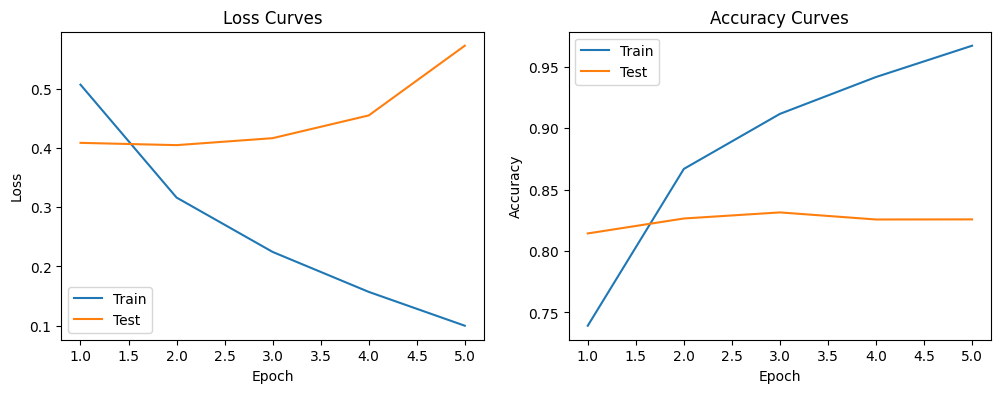

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["test_loss"], label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["test_acc"], label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

# ViT for classification

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import vit_b_16, ViT_B_16_Weights
import matplotlib.pyplot as plt
import timm

In [ ]:
weights = ViT_B_16_Weights.IMAGENET1K_V1

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0
)

classes = train_dataset.classes

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100 * correct / total:.2f}%"
        )

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{100 * correct / total:.2f}%"
            )

    epoch_loss = total_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=10
)
for param in model.parameters():
    param.requires_grad = False


for param in model.head.parameters():
    param.requires_grad = True
model = model.to(device)

print(model.head)

print(
    f"\nTrainable Parameters: "
    f"{count_parameters(model):,}"
)

Linear(in_features=192, out_features=10, bias=True)

Trainable Parameters: 1,930


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )


Epoch 1/5


Training:   0%|          | 0/196 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 1.7693 | Train Acc: 0.4099 | Test Loss: 1.2160 | Test Acc: 0.6363

Epoch 2/5


Training:   0%|          | 0/196 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.7483 | Train Acc: 0.7610 | Test Loss: 0.7240 | Test Acc: 0.7684

Epoch 5/5


Training:   0%|          | 0/196 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 0.6970 | Train Acc: 0.7728 | Test Loss: 0.6853 | Test Acc: 0.7785


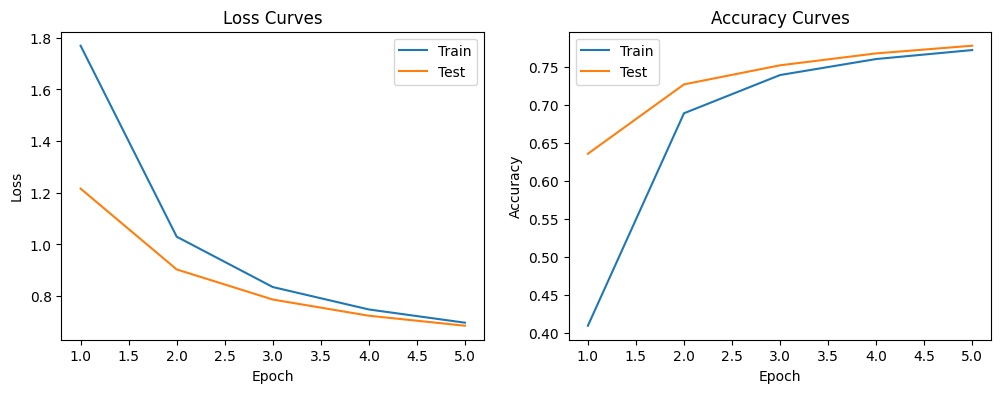

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train")
plt.plot(epochs, history["test_loss"], label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train")
plt.plot(epochs, history["test_acc"], label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()